# **DSC - 3) Random Forest**

An ensemble of decision trees trained on bootstrapped data with randomly selected features.

**References**
> - Google Advanced Data Analytics Certificate
> - Gema Fernández, 2024 - Fundamentos de Ciencia de Datos en R [(Book)](https://cdr-book.github.io/index.html)

## **3.0) Theoretical background**

### **3.0.1) Bootstrap**

A statistical techinque commonly used to estimate properties of an estimator (such as mean, variance, confidence intervals, etc.) by resampling data. It' is particularly useful when the theoretical distribution of the estimator in complicated or unknown.

**Key features**
> _Resampling method:_ Bootstrap involves repeatedly drawing samples, with replacement, formn the observed dataset to create "bootstrap" samples. Each sample has the same size as the original dataset.
> 
> _Non-parametric:_ It does not make assumptions about the underlying distirbution of the data, making it versatile and robust,
> 
> _Confidence intervals and Bias Estimation:_ Bootstrap is often used to compute confidence intervals and assess the bias or variance of an estimator.
> 
> _Monte Carlo Method:_ Since it relies on simulaton and randonm sampling, it is a Monte Carlo technique.

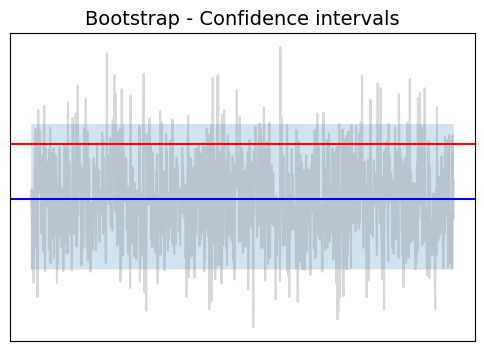

In [123]:
# Used libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define sample and population parameters
sample = pd.Series(np.random.normal(100, 100, 15))
results = []

# Bootstrap sample elements
for i in range(10**3):
    bootstrap = sample.sample(15, replace=True)
    results += [bootstrap.mean()]
results = pd.Series(results)

# Plot results
plt.figure(figsize=(6,4))
plt.plot(results, alpha=0.30, color="gray")
plt.axhline(100, color="red")
plt.axhline(pd.Series(results).mean(), color="blue")
p05 = np.percentile(results, 5)
p95 = np.percentile(results, 95)
plt.fill_between([i for i in range(10**3)], p05, p95, alpha=0.20)
plt.xticks([]), plt.yticks([]), plt.title("Bootstrap - Confidence intervals", fontsize=14)
plt.show()

### **3.0.2) Bagging**

Bagging (short for Bootstrap Aggregation) is a machine learning ensemble techinque designed to improve the stability and accuracy of machine learning models. It is particularly effective for reducing variance and preventing overfitting, especially for high.variance models like decision trees. A base learner is trained on an unique subset of the data. The base learners are expected to be unneficient by themselves, almost like a weak learner; the aggregation of all provides an adequate prediction.

**Key concepts**
> _Bootstrap sampling:_ Multiple sibsets of the training data are created by sampling with replacement. Each subset, or "bootstrap sample", has the same size as the original trainig set but may contain duplicates
>
> _Model training:_ A separate model is trained on each bootstrap sample independently. These models are typically of the same type, such as decision trees.
>
> _Aggregation:_ For regression tasks the predictions from all models are averaged. For classification tasks a majority bote is taken fron all models to determine tghe final prediction.

### **3.0.3) Random forest**

An ensemble model of prediction trees, that are all aggregated to provide a final prediction. Each tree uses bootstrap, while also the selection of used predictor variables is also randomized. No single tree all the predictor variables in the dataset. The most important parameters of the random forest are

> _Number of trees:_ The amount of individual trees to be trained as part of the forest
> 
> _Max variables:_ Controls the number of randomly selected features to extract the subset with wich an individual tree will be traiend

## **3.1) Prepare for execution**

### **3.0.1) Import libraries**

In [248]:
# Supress warnings
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# General purpose
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
from sklearn import datasets

# Used for modelling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

# Used to perform multidimensional scaling
from sklearn.manifold import MDS
import scipy.spatial.distance as distance
from sklearn.metrics import pairwise

# Used for ANOVA test
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Assess the fitted model
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score

# Model selection
from sklearn.model_selection import GridSearchCV, PredefinedSplit

### **3.0.2) Used dataset**

#### **3.0.2.1) Load dataset**

In [130]:
# Load dataset
sk_wine = datasets.load_wine()
df_data = pd.DataFrame(data=sk_wine.data, columns=sk_wine["feature_names"])
df_data["wine_type"] = pd.Series(sk_wine["target"]).map({0:"cabernet", 1:"merlot", 2:"shiraz"})
df_data.rename({"od280/od315_of_diluted_wines": "protein"}, axis=1, inplace=True)
features = df_data.columns.to_list()
features.remove("wine_type")

# Block breaker
print("="*100, "\nTarget variable distribution in the dataset:","\n")
print(df_data["wine_type"].value_counts(normalize=True).round(3))
print("="*100)

Target variable distribution in the dataset: 

wine_type
merlot      0.399
cabernet    0.331
shiraz      0.270
Name: proportion, dtype: float64


#### **3.0.2.2) Exploratory data analysis**

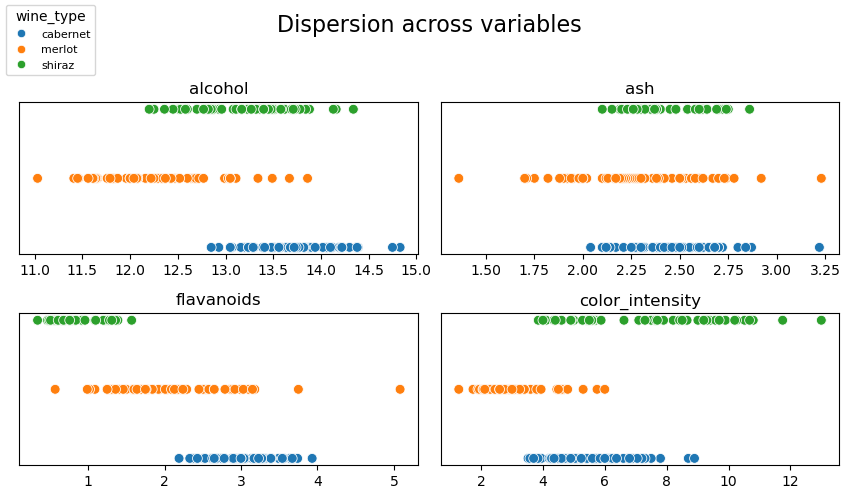

In [131]:
# Used to extract legend to be displayed later
scatter_ax = plt.gca()
sns.scatterplot(data=df_data, x="alcohol", y="wine_type", hue="wine_type", ax=scatter_ax)
handles, labels = scatter_ax.get_legend_handles_labels()
plt.close()

# Plot grid of charts
fig, axes = plt.subplots(2, 2, figsize=(8.5,5))
variables = ["alcohol", "ash", "flavanoids", "color_intensity"]
for i, ax in enumerate(fig.axes):
    sns.scatterplot(df_data, x=variables[i], y="wine_type", ax=ax, hue="wine_type", legend=False, s=50)
    ax.set_title(variables[i], fontsize=12), ax.set_ylabel(""), ax.set_yticks([]), ax.set_xlabel(""), ax.set_ylim(-0.1,2.1)

# Add legend, adjust and show plot
plt.suptitle("Dispersion across variables", fontsize=16)
fig.legend(handles, labels, fontsize=8, loc="upper left", ncol=1, title='wine_type')
plt.tight_layout(rect=[0, 0, 1, .95])
plt.show()

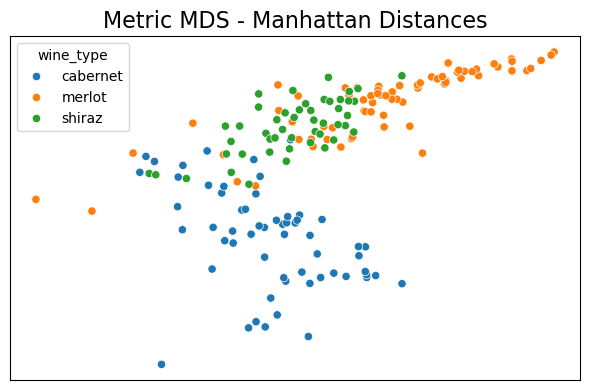

In [132]:
# Calculate NMDS based on city block distances
dissim = pairwise.manhattan_distances(df_data[features])
mds = MDS(n_components=2, dissimilarity="precomputed", metric=True, random_state=314159)
mds = mds.fit_transform(dissim)

# Plot results
plt.figure(figsize=(6,4))
sns.scatterplot(x=mds[:,0], y=mds[:,1], hue=df_data["wine_type"])
plt.title("Metric MDS - Manhattan Distances",fontsize=16), plt.xticks([]), plt.yticks([]), plt.tight_layout()
plt.show()

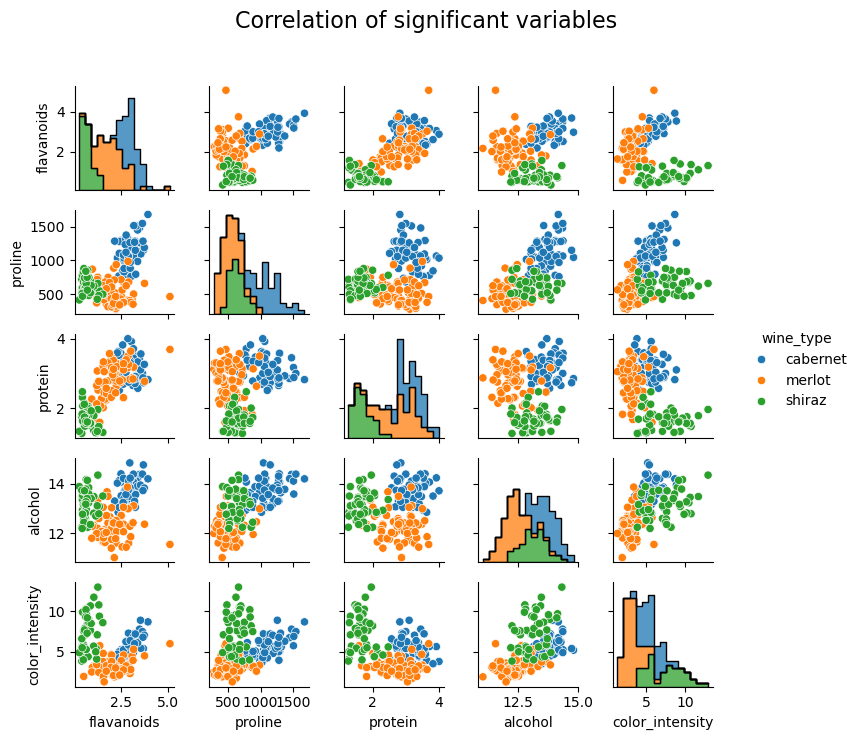

In [134]:
# Scale features using a z-score
df_temporal = (df_data[features] - df_data[features].mean()) / df_data[features].std(ddof=1)
df_temporal = pd.concat([df_temporal, df_data["wine_type"]], axis=1)

# Adjust model and run one way ANOVA to select variables of interest
temporal = {}
for variable in features:
    model_ols = ols(formula=variable+" ~ C(wine_type)", data=df_data).fit()
    temporal[variable] = sm.stats.anova_lm(model_ols, typ=2).iloc[0,3]
variables = pd.Series(temporal).sort_values(ascending=True).index.to_list()[:5]

# Slice df to preserve only variables of interest
df_temporal = df_data[variables+["wine_type"]].copy()

# Correlation plot
grid = sns.PairGrid(df_temporal, hue="wine_type", height=1.5)
grid.map_diag(sns.histplot, multiple="stack", element="step", bins=15), grid.map_offdiag(sns.scatterplot)
grid.add_legend(), grid.fig.suptitle("Correlation of significant variables", fontsize=16), plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

## **3.2) Run the Random Forest model**

**Notes**
> Train data is set to be only the 30% of the dataset. Hidding data to the model, it behaves like if the data was not a toy dataset.

### **3.2.1) Effect of number of trees**

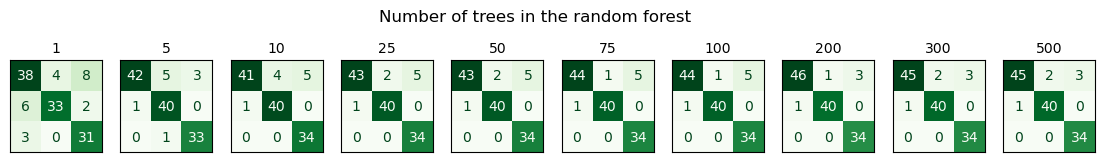

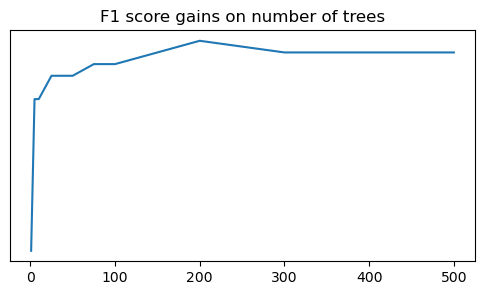

In [222]:
# Shape the data
X = df_data[features]
y = df_data["wine_type"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.70, stratify=y, random_state=314159)

# Define number of trees and prepare plot
n_trees = [1,5,10,25,50,75,100,200,300,500]
fig, axes = plt.subplots(1,10, figsize=(14,2))

# Iterate over each number of trees
results = []
for i,n in enumerate(n_trees): 

    # Fit model and predict
    model_rf = RandomForestClassifier(random_state=314159, n_estimators=n, max_depth=5).fit(X_train, y_train)
    y_pred = model_rf.predict(X_test)
    results += [f1_score(y_test, y_pred, average="micro")]

    # Plot confusion matrix
    conf_mx = confusion_matrix(y_test, y_pred, labels=y_test.unique())
    ConfusionMatrixDisplay(conf_mx, display_labels=y_test.unique()).plot(colorbar=False, cmap="Greens", ax=axes[i])
    axes[i].set_xticks([]), axes[i].set_yticks([]), axes[i].set_xlabel(""), axes[i].set_ylabel("")
    axes[i].set_title(n, fontsize=10)

# SHow confusion matrices plot
plt.suptitle("Number of trees in the random forest")
plt.show()

# Show increase on recall score
plt.figure(figsize=(6,3))
plt.plot(n_trees, results)
plt.title("F1 score gains on number of trees")
plt.yticks([])
plt.show()

### **3.2.2) Grid search for optimal parameters**

In [220]:
%%time

# Shape the data
X = df_data[features]
y = df_data["wine_type"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.70, stratify=y, random_state=314159)

# Define hyperparametrs space
parameters_grid = {"max_depth":[2,3,4,5,None], "min_samples_leaf":[1,2,3], "min_samples_split":[2,3,4],
                 "max_features":[2,3,4,5,6], "n_estimators":[10, 50, 100, 200, 250, 500]}

# Perform the grid search
model_rf = RandomForestClassifier(random_state=314159)
model_gsrf = GridSearchCV(model_rf, parameters_grid, scoring="f1_micro", cv=5).fit(X_train, y_train)

# Block breaker
print("="*100)
print("Best parameters")
print(model_gsrf.best_params_)
print("="*100)

Best parameters
{'max_depth': 3, 'max_features': 2, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 10}
CPU times: user 7min 12s, sys: 1.92 s, total: 7min 14s
Wall time: 7min 15s


### **3.2.3) Validate with separate subset**

The Grid Search CV function was set to perform a k-fold validation process, in this cell a separate validation set is used, reducing the execution time.

In [249]:
%%time

# Shape the data (32.5% test, 35% train, 32.5% validation)
X = df_data[features]
y = df_data["wine_type"]
X_temporal, X_test, y_temporal, y_test = train_test_split(X, y, test_size=0.35, stratify=y, random_state=314159)
X_train, X_validate, y_train, y_validate = train_test_split(X_temporal, y_temporal, test_size=0.55, stratify=y_temporal, random_state=314159)

# Define identifier for training and validation datasets
split_index = [-1 if x in X_train.index else 0 for x in X_temporal.index]

# Run Grid Searvh
model_rf = RandomForestClassifier(random_state=314159)
custom_split = PredefinedSplit(split_index)

# Define hyperparametrs space
parameters_grid = {"max_depth":[2,3,4,5,None], "min_samples_leaf":[1,2,3], "min_samples_split":[2,3,4],
                 "max_features":[2,3,4,5,6], "n_estimators":[10, 50, 100, 200, 250, 500]}

# Run Grid Search algorithm
model_gsrf = GridSearchCV(model_rf, parameters_grid, scoring="f1_micro", cv=custom_split).fit(X_temporal, y_temporal)

# Block breaker
print("="*100)
print("Best parameters")
print(model_gsrf.best_params_)
print("="*100)

Best parameters
{'max_depth': 2, 'max_features': 2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}
CPU times: user 1min 27s, sys: 432 ms, total: 1min 28s
Wall time: 1min 28s
